In [23]:
import os, re, io
import pandas as pd
import numpy as np
import nibabel as nib
from collections import Counter
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, ListedColormap
from matplotlib.cm import ScalarMappable, get_cmap
from nilearn import datasets, plotting, image
from PIL import Image, ImageDraw, ImageFont
import matplotlib.font_manager as fm
from collections import defaultdict

# M/EEG plotting

### Heatmap Based on PERCENTAGE of studies analyzing a given time window (Figure 2a)

In [68]:
# load file
stimuli_df = pd.read_excel(f"../scratch_plotting.xlsx", sheet_name = "TWs_for_table")

def extract_time_windows_by_study(data: pd.DataFrame, coord_col: str = 'component', study_col: str = 'study_id'):
    """
    Extracts time windows from a DataFrame column and tracks which study reported each.

    Parameters
    ----------
    data : pd.DataFrame
        Input data with at least two columns: study ID and time window strings (e.g., '100-200,300-400').
    coord_col : str
        Name of the column containing time window strings.
    study_col : str
        Name of the column containing study identifiers.

    Returns
    -------
    ms_to_studies : dict[int, set]
        Dictionary mapping milliseconds to sets of study IDs.
    n_studies : int
        Total number of unique studies.
    """
    pattern = r'(\d+)-(\d+)'
    ms_to_studies = defaultdict(set)

    for _, row in data.dropna(subset=[coord_col]).iterrows():
        study = row[study_col]
        matches = re.findall(pattern, str(row[coord_col]))
        for start, end in [(int(s), int(e)) for s, e in matches]:
            if end <= 1400:  # limit to 0–1400ms
                for t in range(start, end + 1):
                    ms_to_studies[t].add(study)

    n_studies = data[study_col].nunique()
    return ms_to_studies, n_studies


def compute_percentage_timeline(ms_to_studies: dict[int, set], n_studies: int, max_time: int = 1400) -> np.ndarray:
    """
    Converts the ms_to_studies dict into a timeline array of percentage values.

    Returns
    -------
    timeline : np.ndarray
        Array of percentages of studies for each millisecond from 0 to max_time.
    """
    return np.array([
        (len(ms_to_studies.get(t, set())) / n_studies) * 100
        for t in range(max_time + 1)
    ])


def plot_heatmap_timeline(timeline: np.ndarray, cmap, norm, save_path: str = None):
    """
    Plots a horizontal heatmap timeline of percentage of studies per millisecond, without a color bar.

    Parameters
    ----------
    timeline : np.ndarray
        Array of percentage values per millisecond.
    cmap : matplotlib.colors.Colormap
        Colormap to use for the heatmap.
    norm : matplotlib.colors.Normalize
        Normalization for color scaling (should be Normalize(0, 100)).
    save_path : str, optional
        Path to save the figure. If None, the figure is not saved.
    """
    fig, ax = plt.subplots(figsize=(10, 2.5))

    for i in range(len(timeline)):
        ax.plot([i, i + 1], [1, 1], linestyle='-', linewidth=10, color=cmap(norm(timeline[i])))

    ax.set_yticks([])
    ax.set_ylim(0.9, 1.1)
    ax.set_title('     ')
    ax.set_xlabel('Time (ms)')
    ax.set_xlim(0, 1400)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Saved to: {save_path}")

    plt.show()


Saved to: ./figures/meeg_timeline_heatmap.png


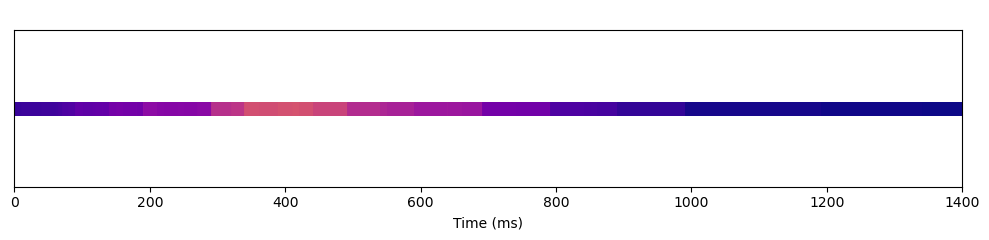

In [69]:
# extract study-to-ms mapping and total study count
ms_to_studies, n_studies = extract_time_windows_by_study(stimuli_df, 'component', 'study_id')

# compute timeline (percent coverage per ms)
timeline = compute_percentage_timeline(ms_to_studies, n_studies)

# we want the same color scale
cmap = plt.colormaps['plasma']
norm = Normalize(vmin=0, vmax=100)
#norm = Normalize(vmin=timeline.min(), vmax=timeline.max())  # adaptive scale

# plot
save_path = os.path.join("./figures/meeg_timeline_heatmap.png")
plot_heatmap_timeline(timeline, cmap, norm, save_path=save_path)

### Topomap Based on PERCENTAGE of M/EEG studies analyzing a coarse region (Figure 2b)

/var/folders/tw/kccyk0b139z3w564phcppjnm0000gp/T/ipykernel_42139/320248066.py:86: RuntimeWarning: invalid value encountered in sqrt
  ear_left_x = -np.sqrt(0.2**2 - (ear_y**2)) - 1.1
/var/folders/tw/kccyk0b139z3w564phcppjnm0000gp/T/ipykernel_42139/320248066.py:87: RuntimeWarning: invalid value encountered in sqrt
  ear_right_x = np.sqrt(0.2**2 - (ear_y**2)) + 1.1
/var/folders/tw/kccyk0b139z3w564phcppjnm0000gp/T/ipykernel_42139/320248066.py:108: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('plasma')


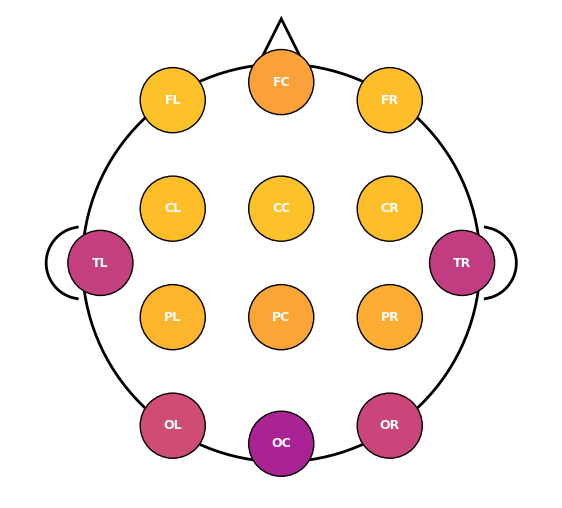

In [14]:

# Coordinates of coarse EEG/MEG regions (for topomap layout)
region_coords = {
    'FL': (-0.6, 0.9), 'FC': (0.0, 1.0), 'FR': (0.6, 0.9),
    'CL': (-0.6, 0.3), 'CC': (0.0, 0.3), 'CR': (0.6, 0.3),
    'PL': (-0.6, -0.3), 'PC': (0.0, -0.3), 'PR': (0.6, -0.3),
    'OL': (-0.6, -0.9), 'OC': (0.0, -1.0), 'OR': (0.6, -0.9),
    'TL': (-1.0, 0.0), 'TR': (1.0, 0.0)
}


def parse_covered_regions(entry):
    """
    Parses a 'Covered_Regions_COARSE' entry into region codes (e.g., FL, CC).
    Supports laterality tags: left, right, bilateral, midline.
    """
    regions = defaultdict(set)
    if not isinstance(entry, str):
        return set()

    entry = entry.upper().replace('-', '_').replace(',', '_')
    tokens = entry.split('_')

    i = 0
    while i < len(tokens):
        part = tokens[i]
        if not part:
            i += 1
            continue

        if all(c in 'FCOPT' for c in part):
            lobes = list(part)
            side = None
            if i + 1 < len(tokens):
                next_token = tokens[i + 1].lower()
                if 'bilateral' in next_token:
                    side = ['L', 'R']
                    i += 1
                elif 'left' in next_token:
                    side = ['L']
                    i += 1
                elif 'right' in next_token:
                    side = ['R']
                    i += 1
                elif 'midline' in next_token:
                    side = ['C']
                    i += 1
            if side is None:
                side = ['L', 'R', 'C']
            for lobe in lobes:
                for s in side:
                    regions[lobe].add(s)
        i += 1

    return {f"{lobe}{s}" for lobe, sides in regions.items() for s in sides}


def aggregate_region_counts(df):
    """
    Aggregates region counts into percentages based on the number of unique studies.
    Returns: dict of region -> percent of studies
    """
    counts = defaultdict(int)
    for val in df['Covered_Regions_COARSE']:
        for region in parse_covered_regions(val):
            counts[region] += 1

    n_studies = df['study'].nunique()
    for region in counts:
        counts[region] = (counts[region] / n_studies) * 100

    # Save to CSV for inspection
    pd.DataFrame(
        sorted(counts.items(), key=lambda x: x[1], reverse=True),
        columns=["Region", "Percentage"]
    ).to_csv("meeg_region_percentages.csv", index=False)

    return counts


def draw_head(ax):
    """Draws a stylized head outline, ears, and nose."""
    head = plt.Circle((0, 0), 1.1, color='black', fill=False, lw=2)
    ax.add_patch(head)

    ear_y = np.linspace(-0.4, 0.4, 100)
    ear_left_x = -np.sqrt(0.2**2 - (ear_y**2)) - 1.1
    ear_right_x = np.sqrt(0.2**2 - (ear_y**2)) + 1.1
    ax.plot(ear_left_x, ear_y, color='black', lw=2)
    ax.plot(ear_right_x, ear_y, color='black', lw=2)

    nose = plt.Polygon([[0, 1.35], [-0.1, 1.15], [0.1, 1.15]],
                       closed=True, fill=False, edgecolor='black', lw=2)
    ax.add_patch(nose)

def plot_region_topomap(region_counts, region_coords):
    """
    Plots a topographic map of EEG/MEG regions based on percentage of studies.
    No colorbar is shown; color is scaled from 0 to 100%.
    """
    fig, ax = plt.subplots(figsize=(7, 7))
    draw_head(ax)

    values = list(region_counts.values())
    if not values:
        print("No regions found to plot.")
        return

    cmap = get_cmap('plasma')
    norm = Normalize(vmin=0, vmax=100)

    for region, percent in region_counts.items():
        coord = region_coords.get(region)
        if coord:
            circle = plt.Circle(coord, 0.18, color=cmap(norm(percent)), ec='black')
            ax.add_patch(circle)
            ax.text(*coord, region, ha='center', va='center', color='white',
                    weight='bold', fontsize=9)

    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.3, 1.4)
    ax.set_aspect('equal')
    ax.axis('off')

    # Save figure without colorbar
    plt.savefig("./figures/meeg_topomap_percent.png", dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

# === Load and plot ===

df = pd.read_excel(
    "../scratch_plotting.xlsx",
    sheet_name="MEEG_ROIs"
)

region_counts = aggregate_region_counts(df)
plot_region_topomap(region_counts, region_coords)


# fMRI / fNIRS plotting

#### We used Pedro's code to extract Harvard-Oxford atlas region MNI coordinates from the various studies in our excel sheet & plot
https://github.com/neurocausal/neurocausal_meta/issues/12

Possible caudate coord: (-12, 9, 6) from study: Liu et al. (2023)
Included studies: 21
Excluded studies: 50
Reasons for exclusion:
reason
Not MNI space    45
Parse error       5
Name: count, dtype: int64
Saved list of excluded studies to 'excluded_studies.csv'
[fetch_atlas_harvard_oxford] Dataset found in /Users/licata/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /Users/licata/nilearn_data/fsl
Heat-map saved to combined_roi_frequency.nii.gz


/var/folders/tw/kccyk0b139z3w564phcppjnm0000gp/T/ipykernel_42139/3614558608.py:145: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('plasma')


Saved plot to: ./figures/combined_roi_plot_no-cerebellum.png


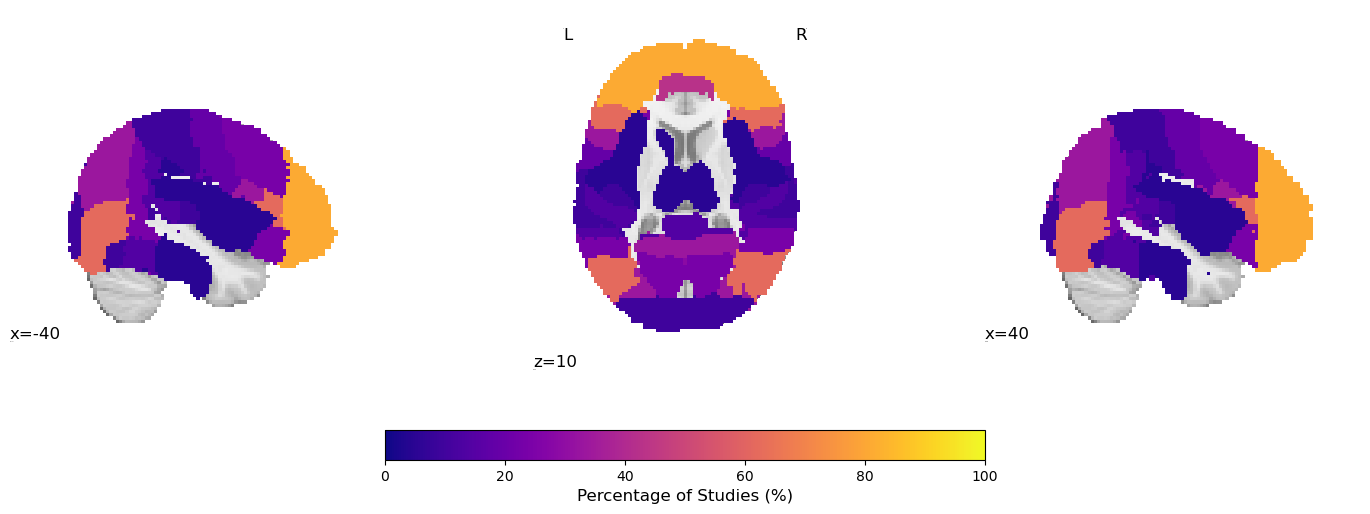

In [58]:

# Coordinate overrides for manual correction
coord_overrides = {
    (-12, 9, 6): "Caudate",                  # Liu et al. (2023)
    (-62, -48, -20): "Cingulate",            # caudal ACC (L)
    (-64, 20, -12): "Cingulate",             # caudal ACC (R)
}

def load_coordinates_and_count_studies(file_path, sheet_name="rois_mapping"):
    df = pd.read_excel(file_path, sheet_name=sheet_name)

    included_rows = []
    excluded_rows = []

    for _, row in df.iterrows():
        study_label = row.get("study", "Unknown study")
        coords_str = str(row.get("coordinates", "")).strip()
        space = row.get("space", "")

        if space != "MNI":
            excluded_rows.append({"study": study_label, "reason": "Not MNI space"})
            continue
        if "NOCOORDINATES" in coords_str or "TABLE" in coords_str or coords_str == "":
            excluded_rows.append({"study": study_label, "reason": "Invalid coordinates"})
            continue

        coords_str_clean = coords_str.strip('()').replace(' ', '').replace(')', '').replace('(', '')
        try:
            coord_list = list(map(int, coords_str_clean.split(',')))
            if len(coord_list) % 3 != 0:
                excluded_rows.append({"study": study_label, "reason": "Malformed coordinate triplet"})
                continue
            for i in range(0, len(coord_list), 3):
                included_rows.append((study_label, tuple(coord_list[i:i+3])))
        except Exception:
            excluded_rows.append({"study": study_label, "reason": "Parse error"})

    used_study_ids = {study for study, _ in included_rows}
    excluded_df = pd.DataFrame(excluded_rows).sort_values("study")

    for study, coord in included_rows:
        if -15 <= coord[0] <= -9 and 8 <= coord[1] <= 12 and 6 <= coord[2] <= 10:
            print("Possible caudate coord:", coord, "from study:", study)
        
    print(f"Included studies: {len(used_study_ids)}")
    print(f"Excluded studies: {excluded_df['study'].nunique()}")
    print("Reasons for exclusion:")
    print(excluded_df.value_counts("reason"))

    if not excluded_df.empty:
        excluded_df.to_csv("excluded_studies.csv", index=False)
        print("Saved list of excluded studies to 'excluded_studies.csv'")

    return included_rows, len(used_study_ids), excluded_df


def generate_cortical_subcortical_map(
    study_coords,
    n_studies: int,
    save_path: str | None = None,
    coord_overrides: dict[tuple[int, int, int], str] | None = None,
):
    """
    Build a %-of-studies heat-map using Harvard-Oxford (cortex+subcortex),
    with explicit coordinate overrides.
    """
    cort = datasets.fetch_atlas_harvard_oxford("cort-maxprob-thr0-2mm")
    sub  = datasets.fetch_atlas_harvard_oxford("sub-maxprob-thr0-2mm")
    cort_data, aff = cort.maps.get_fdata(), cort.maps.affine
    sub_data       = sub.maps.get_fdata()

    atlas_labels = list(cort.labels) + list(sub.labels)
    merged_data  = np.zeros_like(cort_data, dtype=np.float32)
    region_hits, coord_to_lbl = [], []
    overrides = coord_overrides or {}

    for study, coord in study_coords:
        # Manual override
        if coord in overrides:
            target = overrides[coord].lower()
            try_idx = next((i for i, l in enumerate(atlas_labels) if target in l.lower()), None)
            if try_idx is not None:
                region_hits.append(try_idx)
                coord_to_lbl.append((study, coord, f"{atlas_labels[try_idx]} (forced)"))
                continue

        # Harvard-Oxford lookup
        voxel = nib.affines.apply_affine(np.linalg.inv(aff), coord).astype(int)
        label = "No ROI match"
        try:
            v_cort = int(cort_data[tuple(voxel)])
            if 0 < v_cort < len(cort.labels):
                idx, label = v_cort, cort.labels[v_cort]
                region_hits.append(idx)
            else:
                v_sub = int(sub_data[tuple(voxel)])
                if (
                    0 < v_sub < len(sub.labels)
                    and not any(k in sub.labels[v_sub].lower() for k in ("white matter", "cerebral"))
                ):
                    idx = v_sub + len(cort.labels)
                    label = sub.labels[v_sub]
                    region_hits.append(idx)
        except Exception:
            label = "Out of bounds"

        coord_to_lbl.append((study, coord, label))

    # Convert hit counts → percentages
    region_perc = Counter(region_hits)
    for k in list(region_perc):
        region_perc[k] = (region_perc[k] / n_studies) * 100

    # Paint voxels
    for idx, pct in region_perc.items():
        if idx < len(cort.labels):
            merged_data[cort_data == idx] = pct
        elif idx < len(cort.labels) + len(sub.labels):
            merged_data[sub_data == (idx - len(cort.labels))] = pct

    freq_img = nib.Nifti1Image(merged_data, aff)

    if save_path:
        nib.save(freq_img, save_path)
        print(f"Heat-map saved to {save_path}")

    pd.DataFrame(coord_to_lbl,
                 columns=["Study", "MNI Coordinate", "ROI Label"]
                 ).to_csv("mni_to_roi_mapping.csv", index=False)

    return freq_img, region_perc, atlas_labels

def plot_roi_frequency_map(freq_img, region_counts, n_studies, save_path=None):
    """
    Plots 3-view brain activation map (left, axial, right) with a horizontal colorbar at the bottom.
    Scale is fixed from 0 to 100%.
    """
    import matplotlib.pyplot as plt
    from nilearn import plotting
    from matplotlib.colorbar import ColorbarBase
    from matplotlib.cm import ScalarMappable, get_cmap
    from matplotlib.colors import Normalize

    # Fixed normalization
    norm = Normalize(vmin=0, vmax=100)
    cmap = get_cmap('plasma')
    threshold = 0.0

    # Slightly taller canvas to fit colorbar at bottom
    fig = plt.figure(figsize=(15, 6))
    fig.patch.set_facecolor('white')

    # Axes for brain slices
    ax1 = fig.add_axes([0.05, 0.3, 0.25, 0.6])
    ax2 = fig.add_axes([0.375, 0.3, 0.25, 0.6])
    ax3 = fig.add_axes([0.7, 0.3, 0.25, 0.6])

    for ax, cut, mode in zip([ax1, ax2, ax3], [-40, 10, 40], ['x', 'z', 'x']):
        plotting.plot_stat_map(freq_img,
                               display_mode=mode,
                               cut_coords=[cut],
                               threshold=threshold,
                               vmax=100,
                               cmap=cmap,
                               colorbar=False,
                               figure=fig,
                               axes=ax,
                               black_bg=False).annotate(size=0)

    # Horizontal colorbar below
    #ax_cb = fig.add_axes([0.3, 0.08, 0.4, 0.03])  # left, bottom, width, height
    ax_cb = fig.add_axes([0.3, 0.15, 0.4, 0.05])  # [left, bottom, width, height]
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cb = ColorbarBase(ax_cb, cmap=cmap, norm=norm, orientation='horizontal')
    cb.set_label("Percentage of Studies (%)", fontsize=12)
    cb.ax.tick_params(labelsize=10)

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white')
        print(f"Saved plot to: {save_path}")

    plt.show()

# === Run the Pipeline ===

mni_coords, n_studies, excluded_df = load_coordinates_and_count_studies(
    "../scratch_plotting.xlsx", sheet_name="fMRI-fNIRS_ROIs"
)

roi_img, roi_counts, roi_labels = generate_cortical_subcortical_map(
    study_coords=mni_coords,
    n_studies=n_studies,
    save_path="combined_roi_frequency.nii.gz",
    coord_overrides=coord_overrides
)

plot_roi_frequency_map(roi_img, roi_counts, n_studies, save_path="./figures/combined_roi_plot_no-cerebellum.png")


# Merge the two images and create the final Figure 2 for the paper

## Stacked vertically

In [70]:
## Now merge with Figure 2b & the M/EEG map above

def combine_three_figures_vertically(image_a_path, image_b_path, image_c_path,
                                     output_path="combined_figure3.png",
                                     labels=("a)", "b)", "c)"),
                                     target_height=1000, pad=30):
    """
    Stacks three images vertically with matching height and centered width.
    Adds panel labels at the top-left of each image.
    """
    def resize_to_height(img, height):
        ratio = height / img.height
        new_width = int(img.width * ratio)
        return img.resize((new_width, height), Image.LANCZOS)

    img_a = resize_to_height(Image.open(image_a_path), target_height)
    img_b = resize_to_height(Image.open(image_b_path), target_height)
    img_c = resize_to_height(Image.open(image_c_path), target_height)

    canvas_width = max(img_a.width, img_b.width, img_c.width)
    total_height = img_a.height + img_b.height + img_c.height + 4 * pad

    combined = Image.new("RGB", (canvas_width, total_height), "white")

    # Paste image A
    offset_y = pad
    offset_x = (canvas_width - img_a.width) // 2
    combined.paste(img_a, (offset_x, offset_y))

    # Paste image B
    offset_y += img_a.height + pad
    offset_x = (canvas_width - img_b.width) // 2
    combined.paste(img_b, (offset_x, offset_y))

    # Paste image C
    offset_y += img_b.height + pad
    offset_x = (canvas_width - img_c.width) // 2
    combined.paste(img_c, (offset_x, offset_y))

    # Load font
    draw = ImageDraw.Draw(combined)
    try:
        font_path = fm.findfont("DejaVu Sans")
        font = ImageFont.truetype(font_path, 70)
    except Exception as e:
        print("Font fallback due to:", e)
        font = ImageFont.load_default()

    # Label positions
    y_positions = [pad, img_a.height + 2 * pad, img_a.height + img_b.height + 3 * pad]
    for label, y in zip(labels, y_positions):
        draw.text((30, y + 10), label, fill="black", font=font)

    combined.save(output_path)
    print(f"Saved combined figure to: {output_path}")


In [71]:
import os

dir_path = "./figures"
meeg_timeline_path = os.path.join(dir_path, "meeg_timeline_heatmap.png")
meeg_map_path      = os.path.join(dir_path, "meeg_topomap_percent.png")  # Replace with actual
fmri_roi_path      = os.path.join(dir_path, "combined_roi_plot_no-cerebellum.png")

combine_three_figures_vertically(
    image_a_path=meeg_timeline_path,
    image_b_path=meeg_map_path,
    image_c_path=fmri_roi_path,
    output_path=os.path.join(dir_path, "final_figure_combined_vertical.png")
)

Saved combined figure to: ./figures/final_figure_combined_vertical.png


## Stacked horiztonally for M/EEG plots with fMRI/fNIRS vertically stacked underneath

In [72]:
def combine_ab_horiz_c_vert(image_a_path, image_b_path, image_c_path,
                             output_path="combined_figure.png",
                             labels=("a)", "b)", "c)"),
                             target_height=1000, pad=30):
    """
    Combines a) and b) horizontally, then stacks c) underneath. All images are resized to maintain balance.
    Adds panel labels to each subfigure.
    """
    def resize_to_height(img, height):
        ratio = height / img.height
        new_width = int(img.width * ratio)
        return img.resize((new_width, height), Image.LANCZOS)

    # Load and resize top row images (a and b)
    #img_a = resize_to_height(Image.open(image_a_path), target_height)
    #img_b = resize_to_height(Image.open(image_b_path), target_height)
    # Make a) 90% of the target height; b) stays at full height
    #img_a = resize_to_height(Image.open(image_a_path), int(target_height * 0.7))
    #img_b = resize_to_height(Image.open(image_b_path), target_height)

    img_b = resize_to_height(Image.open(image_b_path), target_height)
    img_a = resize_to_height(Image.open(image_a_path), target_height)
    
    # Now shrink a) AFTER resizing to target height
    a_shrink_ratio = 0.85  # or adjust this as needed
    img_a = img_a.resize(
        (int(img_a.width * a_shrink_ratio), int(img_a.height * a_shrink_ratio)),
        Image.LANCZOS
    )

    top_row_height = target_height
    top_row_width = img_a.width + img_b.width + pad
    img_c = Image.open(image_c_path)

    # Resize img_c to fit width of the combined a+b image
    ratio_c = (top_row_width - pad) / img_c.width
    img_c_resized = img_c.resize((int(img_c.width * ratio_c), int(img_c.height * ratio_c)), Image.LANCZOS)

    canvas_width = top_row_width
    total_height = top_row_height + img_c_resized.height + 3 * pad

    combined = Image.new("RGB", (canvas_width, total_height), "white")

    # Paste a)
    combined.paste(img_a, (0, pad))
    # Paste b)
    combined.paste(img_b, (img_a.width + pad, pad))
    # Paste c)
    offset_c_x = (canvas_width - img_c_resized.width) // 2
    combined.paste(img_c_resized, (offset_c_x, top_row_height + 2 * pad))

    # Add labels
    draw = ImageDraw.Draw(combined)
    try:
        font_path = fm.findfont("DejaVu Sans")
        font = ImageFont.truetype(font_path, 40)
    except Exception as e:
        print("Font fallback due to:", e)
        font = ImageFont.load_default()

    draw.text((30, pad + 10), labels[0], fill="black", font=font)
    draw.text((img_a.width + pad + 30, pad + 10), labels[1], fill="black", font=font)
    draw.text((30, top_row_height + 2 * pad + 10), labels[2], fill="black", font=font)

    combined.save(output_path)
    print(f"Saved combined figure to: {output_path}")


dir_path = "./figures"
meeg_timeline_path = os.path.join(dir_path, "meeg_timeline_heatmap.png")
meeg_map_path      = os.path.join(dir_path, "meeg_topomap_percent.png")  # Replace with actual
fmri_roi_path      = os.path.join(dir_path, "combined_roi_plot_no-cerebellum.png")

combine_ab_horiz_c_vert(
    image_a_path=meeg_timeline_path,
    image_b_path=meeg_map_path,
    image_c_path=fmri_roi_path,
    output_path=os.path.join(dir_path, "final_figure_combined_v1.png")
)

Saved combined figure to: ./figures/final_figure_combined_v1.png


### Trying to resize Figure 2a so it doesn't smush Figure 2b

In [73]:
def combine_ab_horiz_c_vert(image_a_path, image_b_path, image_c_path,
                             output_path="combined_figure.png",
                             labels=("a)", "b)", "c)"),
                             target_height=1000, pad=30):
    """
    Combines a) and b) horizontally, then stacks c) underneath. All images are resized to maintain balance.
    Adds panel labels to each subfigure.
    """
    def resize_to_height(img, height):
        ratio = height / img.height
        new_width = int(img.width * ratio)
        return img.resize((new_width, height), Image.LANCZOS)

    # Load and resize image a to target height
    img_a = resize_to_height(Image.open(image_a_path), target_height)

    # Shrink only the width of a), keep full height
    a_shrink_ratio = 0.7  # Adjust as needed
    img_a = img_a.resize((int(img_a.width * a_shrink_ratio), img_a.height), Image.LANCZOS)

    # Load image b (we will scale it to fill remaining width after img_a + pad)
    img_b_orig = Image.open(image_b_path)
    img_b = resize_to_height(img_b_orig, target_height)

    # Compute remaining width for b to match final width
    top_row_width = img_a.width + img_b.width + pad
    b_fill_width = int(top_row_width - img_a.width - pad)
    b_new_height = int(img_b.height * (b_fill_width / img_b.width))
    img_b = img_b.resize((b_fill_width, b_new_height), Image.LANCZOS)

    # Resize c to fit the combined width
    img_c = Image.open(image_c_path)
    ratio_c = (top_row_width - pad) / img_c.width
    img_c_resized = img_c.resize((int(img_c.width * ratio_c),
                                  int(img_c.height * ratio_c)), Image.LANCZOS)

    # Compute canvas dimensions
    canvas_width = img_a.width + img_b.width + pad
    top_row_height = max(img_a.height, img_b.height)
    total_height = top_row_height + img_c_resized.height + 3 * pad

    combined = Image.new("RGB", (canvas_width, total_height), "white")

    # Paste a)
    combined.paste(img_a, (0, pad))
    # Paste b)
    combined.paste(img_b, (img_a.width + pad, pad))
    # Paste c)
    offset_c_x = (canvas_width - img_c_resized.width) // 2
    combined.paste(img_c_resized, (offset_c_x, top_row_height + 2 * pad))

    # Add labels
    draw = ImageDraw.Draw(combined)
    try:
        font_path = fm.findfont("DejaVu Sans")
        font = ImageFont.truetype(font_path, 80)
    except Exception as e:
        print("Font fallback due to:", e)
        font = ImageFont.load_default()

    draw.text((30, pad + 10), labels[0], fill="black", font=font)
    draw.text((img_a.width + pad + 30, pad + 10), labels[1], fill="black", font=font)
    draw.text((30, top_row_height + 2 * pad + 10), labels[2], fill="black", font=font)

    combined.save(output_path)
    print(f"Saved combined figure to: {output_path}")


In [74]:

dir_path = "./figures"
meeg_timeline_path = os.path.join(dir_path, "meeg_timeline_heatmap.png")
meeg_map_path      = os.path.join(dir_path, "meeg_topomap_percent.png")  # Replace with actual
fmri_roi_path      = os.path.join(dir_path, "combined_roi_plot_no-cerebellum.png")

combine_ab_horiz_c_vert(
    image_a_path=meeg_timeline_path,
    image_b_path=meeg_map_path,
    image_c_path=fmri_roi_path,
    output_path=os.path.join(dir_path, "Figure3_new.png")
)

Saved combined figure to: ./figures/Figure3_new.png
